# Extraction using new algo
1. Use class UmapAlgo to calculate all start points
2. Extract from -3000 step to +2000 step around start point
3. Store in such a way so that you can separate partial an full later
4. Save this local order data

In [54]:
%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
from tes.analysis import AnalysisFunc
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
reader = DataRead()
analyse=AnalysisFunc()
algo = AlgoParFull()
algoumap=UmapAlgo()

#### To extract global order

In [8]:
reader.data_read_bz2('raw/workstation/tes_peri_go.bz2').shape

(40000, 200)

In [ ]:
reader.new_algo_ext(200,"raw/workstation/tes_peri_go.bz2","raw/workstation/tes_peri_lo.bz2")

In [3]:
df_loc=reader.data_read_bz2("raw/workstation/tes_mob_lo.bz2")

In [ ]:
reader.ext_node_community(df_loc,0.5,"raw/workstation/tes_mob_nc.bz2")

In [4]:
# check for already stored data
df_fn= reader.data_read_bz2("raw/workstation/tes_fn_go.bz2") 
#df_loc_fn = reader.data_read_bz2("raw/workstation/tes_fn_lo.bz2")

In [ ]:
df_peri = reader.data_read_bz2("raw/workstation/tes_peri_go.bz2")
#df_loc_peri = reader.data_read_bz2("raw/workstation/tes_peri_lo.bz2")

In [5]:
df_fn_nc=reader.data_read_bz2("raw/workstation/tes_fn_nc.bz2")                                                                 

#### Visualize transition

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


NameError: name 'thresh_go' is not defined

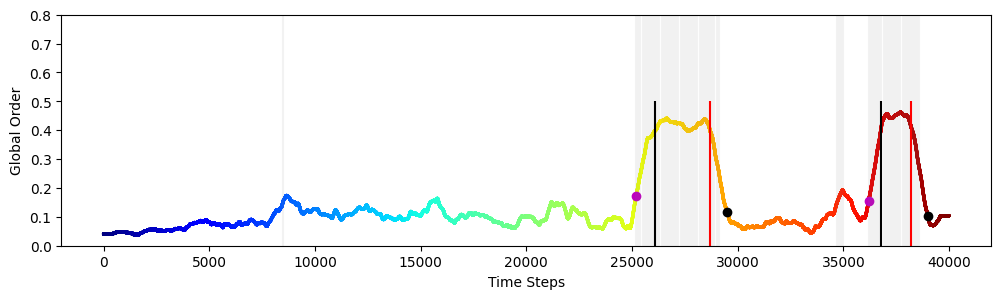

In [ ]:
n=6
# find start stop points
pts=algoumap.compute_parameters(df_fn[n])
algoumap.plot_transition(df_fn[n],pts['start_points'],pts['stop_points'])
plt.ylim(0,0.8)

# for i in comm_pts['start_comm']:
#     plt.vlines(i,0,0.5, color='k')
# for i in comm_pts['stop_comm']:
#     plt.vlines(i,0,0.5, color='r')


# for i, threshold in enumerate(thresh_go):
#     if i==0:
#         plt.hlines(threshold,0,40000, color='m')
#     elif i==1:
#         plt.hlines(threshold,0,40000, color='c')
#     elif i==2:
#         plt.hlines(threshold,0,40000, color='y')
#     else:
#         plt.hlines(threshold,0,40000, color='g')


#### Find points where 90% of global order is crossed in a transition
- If transition never falls down, take the last timestep

In [7]:
def get_crossing_go(df, pts):
    """Get start and stop points where global order is 90%

    Args:
        df (dataframe): Global order dataframe of timesteps x iterations
        pts (dictionary): Start and Stop points of transition
        

    Returns:
        dictionary: keys are 'start_comm' and 'stop_comm' with respective lists of points
    """
    # Ensure stop points match start points
    if len(pts['start_points']) > len(pts['stop_points']):
        pts['stop_points'].append(len(df) - 1)

    _data = df.rolling(800, center=True).mean().ffill().bfill()
    start_comm=[]
    stop_comm=[]
    thresh_go=[]
    all_crossings = []
    for start, stop in zip(pts['start_points'], pts['stop_points']):
        #_data = df_fn[n].iloc[start:stop].rolling(800, center=True).mean().ffill().bfill()
        values = _data.iloc[start:stop].values
        window_values = values.copy()

        max_val = values.max()
        threshold = 0.90 * max_val
        thresh_go.append(threshold)
        above_threshold = window_values >= threshold

        # Detect transitions
        transitions = np.diff(above_threshold.astype(int))
        rising_edges = np.where(transitions == 1)[0]      # below → above
        falling_edges = np.where(transitions == -1)[0]     # above → below

        # Combine and sort all crossings
        #all_edges = np.sort(np.concatenate((rising_edges, falling_edges)))
        all_edges = np.concatenate((rising_edges, falling_edges))
        actual_indices = all_edges + start

        if len(actual_indices) > 0:
            all_crossings.extend(actual_indices)
            start_comm.append(actual_indices[0])
            # stop_comm.append(actual_indices[-1])
            if actual_indices[0]!=actual_indices[-1]:
                stop_comm.append(actual_indices[-1])
            elif stop==39999:
                # to take care of transitions which never fall back
                stop_comm.append(stop)
            else:
                # to take care of rolling window in the end cases
                print('this cell')
                stop_comm.append(stop+400)

            #print(f'Start {start} Stop {stop} Threshold {threshold}')
            #print(f'Crossing points (rising & falling): {actual_indices}')
        else:
            #print(f'No threshold crossing found between {start} and {stop}')
            closest_idx = np.argmin(np.abs(window_values - threshold))
            actual_idx = int(closest_idx) + start
            #print(f'Closest point to threshold at index: {actual_idx}')
            start_comm.append(start)
            stop_comm.append(stop)

    # print(f'\nTotal number of crossing points found: {len(all_crossings)}')
    # print(f' points {start_comm} ,{stop_comm}, {thresh_go}')
    
    return {'start_comm':start_comm,'stop_comm':stop_comm}

#### Using above function

In [27]:
# find start stop points for transition
pts=algoumap.compute_parameters(df_fn[n])

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [28]:
# find start stop points where global order crosses 90%
comm_pts=get_crossing_go(df_fn[n], pts)

In [29]:
comm_pts

{'start_comm': [26075, 36805], 'stop_comm': [28701, 38188]}

#### Get the binarized matrix
- columns arranged community wise

In [11]:
def get_binairized_matrix(df,trans_start):
    """Gives binarized matrix in desired order. YOu can uncomment plt lines to visualise the matrix.

    Args:
        df (dataframe): node community dataframe only transition part (5000x426)
        trans_start (int): starting point of transition
    Returns:
        dataframe: Binarized dataframe with community ordering
    """
    des_order=reader.get_communities()['des_order']
    mc = analyse.compute_main_cluster(df)
    nc_array = df.values
    nc=nc_array.copy()
    #print(mc)

    binary_mask = np.isclose(nc, mc)
    bm_ordered = binary_mask.T[des_order]

    df_bm=pd.DataFrame(bm_ordered).T
    #trans_start=pts['start_points'][0]
    df_bm.index=list(range(trans_start-3000,trans_start+2000))
    # plt.imshow(df_bm.T, cmap='gray', interpolation='nearest', aspect = 'auto')
    # plt.colorbar()
    # plt.title('Binarised matrix with community ordering')
    return df_bm

#### Checking above function

In [19]:
df_bm=get_binairized_matrix(df_fn_nc.loc[n].iloc[0:5000],pts['start_points'][1])

#### Get community percentage

In [13]:


def get_community_percentage(start, stop, df_bm):
    """
    Calculates community-wise percentage for a given transition range.

    Args:
        start (int/float): starting timestep (e.g., 90% global order timestep)
        stop (int/float): ending timestep (e.g., below 90% global order timestep)
        df_bm (pd.DataFrame): binarised node-community dataframe (timesteps × nodes)
        
    """
    comm_count=reader.get_communities()['comm_val']
    comm_name=reader.get_communities()['name_seq']
    cum_count=np.cumsum(comm_count)

    # Define the time window (handle missing stop)
    if start not in df_bm.index:
        raise ValueError("Start index not found in dataframe")
    if stop in df_bm.index:
        df_slice = df_bm.loc[start:stop]
    else:
        df_slice = df_bm.loc[start:]
    
    results = []

    init = 0
    for count, name in zip(cum_count, comm_name):
        sub_array = df_slice.iloc[:, init:count].values
        tot=sub_array.size
        count_true=np.sum(sub_array)
        percentage=(count_true/tot)*100
        results.append({
            "community": name,
            "total": tot,
            "percentage": percentage
        })
        init = count
    df=pd.DataFrame(results)
    df=df.set_index('community')
    return df


#### Check community percentage

In [20]:
df_gc=get_community_percentage( comm_pts['start_comm'][1], comm_pts['stop_comm'][1], df_bm)

In [18]:
comm_pts['stop_comm'][1]

30100

In [21]:
df_gc

,total,percentage
community,,
MO,43120,70.830241
VIS,38500,65.670130
ORB,26180,90.607334
HTh,33880,77.647580
OLF,27720,92.334055
HIPP,38500,61.818182
MID,53900,45.749536
HIND,66220,5.454545


In [15]:
df_gc

,total,percentage
community,,
MO,15736,79.855109
VIS,14050,89.295374
ORB,9554,98.995185
HTh,12364,97.395665
OLF,10116,100.000000
HIPP,14050,84.768683
MID,19670,57.432639
HIND,24166,2.085575


#### Function which gives community participation for partial and full transitions

In [24]:
itr=n
threshold=0.39874500541287045
pts=algoumap.compute_parameters(df_fn[itr])
cov=algo.compute_coverage(df_fn[itr], pts['start_points'], pts['stop_points'])
ind=algo.compute_num_trans(cov,threshold)

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [26]:
ind['part_ind']

[0]

In [27]:
ind['count_trans']

2

In [ ]:
tran_itr 

[0, 1, 2, 5, 6, 7, 8, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24]

### Class to compute community percentage partially and completely

In [22]:
class CommPercentages:
    def __init__(self):
        self.full_mo_tot=[]
        self.full_mo_per=[]
        self.full_vis_tot=[]
        self.full_vis_per=[]
        self.full_orb_tot=[]
        self.full_orb_per=[] 
        self.full_hth_tot=[]
        self.full_hth_per=[]
        self.full_olf_tot=[]
        self.full_olf_per=[]
        self.full_hipp_tot=[]
        self.full_hipp_per=[] 
        self.full_mid_tot=[]
        self.full_mid_per=[]
        self.full_hind_tot=[]
        self.full_hind_per=[]

        self.part_mo_tot=[]
        self.part_mo_per=[]
        self.part_vis_tot=[]
        self.part_vis_per=[]
        self.part_orb_tot=[]
        self.part_orb_per=[] 
        self.part_hth_tot=[]
        self.part_hth_per=[]
        self.part_olf_tot=[]
        self.part_olf_per=[]
        self.part_hipp_tot=[]
        self.part_hipp_per=[] 
        self.part_mid_tot=[]
        self.part_mid_per=[]
        self.part_hind_tot=[]
        self.part_hind_per=[]

    def store_full_data(self, df_gc):
        self.full_mo_tot.append(df_gc.loc['MO']['total'])
        self.full_mo_per.append(df_gc.loc['MO']['percentage'])

            
        self.full_vis_tot.append(df_gc.loc['VIS']['total'])
        self.full_vis_per.append(df_gc.loc['VIS']['percentage'])

                
        self.full_orb_tot.append(df_gc.loc['ORB']['total'])
        self.full_orb_per.append(df_gc.loc['ORB']['percentage'])


        self.full_hth_tot.append(df_gc.loc['HTh']['total'])
        self.full_hth_per.append(df_gc.loc['HTh']['percentage'])

        
        self.full_olf_tot.append(df_gc.loc['OLF']['total'])
        self.full_olf_per.append(df_gc.loc['OLF']['percentage'])
        print(f'full: {self.full_olf_per}')

        self.full_hipp_tot.append(df_gc.loc['HIPP']['total'])
        self.full_hipp_per.append(df_gc.loc['HIPP']['percentage'])


        self.full_mid_tot.append(df_gc.loc['MID']['total'])
        self.full_mid_per.append(df_gc.loc['MID']['percentage'])


        self.full_hind_tot.append(df_gc.loc['HIND']['total'])
        self.full_hind_per.append(df_gc.loc['HIND']['percentage'])

    def store_part_data(self, df_gc):
        self.part_mo_tot.append(df_gc.loc['MO']['total'])
        self.part_mo_per.append(df_gc.loc['MO']['percentage'])

            
        self.part_vis_tot.append(df_gc.loc['VIS']['total'])
        self.part_vis_per.append(df_gc.loc['VIS']['percentage'])

                
        self.part_orb_tot.append(df_gc.loc['ORB']['total'])
        self.part_orb_per.append(df_gc.loc['ORB']['percentage'])


        self.part_hth_tot.append(df_gc.loc['HTh']['total'])
        self.part_hth_per.append(df_gc.loc['HTh']['percentage'])

        
        self.part_olf_tot.append(df_gc.loc['OLF']['total'])
        self.part_olf_per.append(df_gc.loc['OLF']['percentage'])
        print(f'part: {self.part_olf_per}')


        self.part_hipp_tot.append(df_gc.loc['HIPP']['total'])
        self.part_hipp_per.append(df_gc.loc['HIPP']['percentage'])


        self.part_mid_tot.append(df_gc.loc['MID']['total'])
        self.part_mid_per.append(df_gc.loc['MID']['percentage'])


        self.part_hind_tot.append(df_gc.loc['HIND']['total'])
        self.part_hind_per.append(df_gc.loc['HIND']['percentage'])

    def weighted_avg_and_std(self, values, weights):
        # Convert to NumPy arrays to allow element-wise arithmetic
        values = np.array(values, dtype=float)
        weights = np.array(weights, dtype=float)

        # Weighted mean
        average = np.average(values, weights=weights)

        # Unbiased weighted variance (sample version)
        sum_w = np.sum(weights)
        sum_w2 = np.sum(weights * weights)  # element-wise multiplication
        variance = np.sum(weights * (values - average)**2) / (sum_w - (sum_w2 / sum_w))
        std = np.sqrt(variance)

        return average, std



    def compute_community_participation(self):
        # print(f'Comunity wise participation for Full transiions')
        # print(f'The average MO participation : {np.average(self.full_mo_per,weights=self.full_mo_tot)}')
        # print(f'The average VIS participation : {np.average(self.full_vis_per,weights=self.full_vis_tot)}')
        # print(f'The average ORB participation : {np.average(self.full_orb_per,weights=self.full_orb_tot)}')
        # print(f'The average HTh participation : {np.average(self.full_hth_per,weights=self.full_hth_tot)}')
        # print(f'The average OLF participation : {np.average(self.full_olf_per,weights=self.full_olf_tot)}') 
        # print(f'The average HIND participation : {np.average(self.full_hind_per,weights=self.full_hind_tot)}')
        # print(f'The average HIPP participation : {np.average(self.full_hipp_per,weights=self.full_hipp_tot)}')
        # print(f'The average MID participation : {np.average(self.full_mid_per,weights=self.full_mid_tot)}')

        
        # print(f'Comunity wise participation for Partial transiions')
        # print(f'The average MO participation : {np.average(self.part_mo_per,weights=self.part_mo_tot)}')
        # print(f'The average VIS participation : {np.average(self.part_vis_per,weights=self.part_vis_tot)}')
        # print(f'The average ORB participation : {np.average(self.part_orb_per,weights=self.part_orb_tot)}')
        # print(f'The average HTh participation : {np.average(self.part_hth_per,weights=self.part_hth_tot)}')
        # print(f'The average OLF participation : {np.average(self.part_olf_per,weights=self.part_olf_tot)}')
        # print(f'The average HIND participation : {np.average(self.part_hind_per,weights=self.part_hind_tot)}')
        # print(f'The average HIPP participation : {np.average(self.part_hipp_per,weights=self.part_hipp_tot)}')
        # print(f'The average MID participation : {np.average(self.part_mid_per,weights=self.part_mid_tot)}') 
        
        # avg_full_mo = np.average(self.full_mo_per,weights=self.full_mo_tot)
        # avg_full_vis = np.average(self.full_vis_per,weights=self.full_vis_tot)
        # avg_full_orb = np.average(self.full_orb_per,weights=self.full_orb_tot)
        # avg_full_hth = np.average(self.full_hth_per,weights=self.full_hth_tot)
        # avg_full_olf = np.average(self.full_olf_per,weights=self.full_olf_tot)
        # avg_full_hind = np.average(self.full_hind_per,weights=self.full_hind_tot)
        # avg_full_hipp = np.average(self.full_hipp_per,weights=self.full_hipp_tot)
        # avg_full_mid = np.average(self.full_mid_per,weights=self.full_mid_tot)      

        # avg_part_mo = np.average(self.part_mo_per,weights=self.part_mo_tot)
        # avg_part_vis = np.average(self.part_vis_per,weights=self.part_vis_tot)
        # avg_part_orb = np.average(self.part_orb_per,weights=self.part_orb_tot)
        # avg_part_hth = np.average(self.part_hth_per,weights=self.part_hth_tot)
        # avg_part_olf = np.average(self.part_olf_per,weights=self.part_olf_tot)
        # avg_part_hind = np.average(self.part_hind_per,weights=self.part_hind_tot)
        # avg_part_hipp = np.average(self.part_hipp_per,weights=self.part_hipp_tot)
        # avg_part_mid = np.average(self.part_mid_per,weights=self.part_mid_tot)

        # FULL transitions
        avg_full_mo, std_full_mo = self.weighted_avg_and_std(self.full_mo_per, self.full_mo_tot)
        avg_full_vis, std_full_vis = self.weighted_avg_and_std(self.full_vis_per, self.full_vis_tot)
        avg_full_orb, std_full_orb = self.weighted_avg_and_std(self.full_orb_per, self.full_orb_tot)
        avg_full_hth, std_full_hth = self.weighted_avg_and_std(self.full_hth_per, self.full_hth_tot)
        avg_full_olf, std_full_olf = self.weighted_avg_and_std(self.full_olf_per, self.full_olf_tot)
        avg_full_hind, std_full_hind = self.weighted_avg_and_std(self.full_hind_per, self.full_hind_tot)
        avg_full_hipp, std_full_hipp = self.weighted_avg_and_std(self.full_hipp_per, self.full_hipp_tot)
        avg_full_mid, std_full_mid = self.weighted_avg_and_std(self.full_mid_per, self.full_mid_tot)

        # PARTIAL transitions
        avg_part_mo, std_part_mo = self.weighted_avg_and_std(self.part_mo_per, self.part_mo_tot)
        avg_part_vis, std_part_vis = self.weighted_avg_and_std(self.part_vis_per, self.part_vis_tot)
        avg_part_orb, std_part_orb = self.weighted_avg_and_std(self.part_orb_per, self.part_orb_tot)
        avg_part_hth, std_part_hth = self.weighted_avg_and_std(self.part_hth_per, self.part_hth_tot)
        avg_part_olf, std_part_olf = self.weighted_avg_and_std(self.part_olf_per, self.part_olf_tot)
        avg_part_hind, std_part_hind = self.weighted_avg_and_std(self.part_hind_per, self.part_hind_tot)
        avg_part_hipp, std_part_hipp = self.weighted_avg_and_std(self.part_hipp_per, self.part_hipp_tot)
        avg_part_mid, std_part_mid = self.weighted_avg_and_std(self.part_mid_per, self.part_mid_tot)


        return {'avg_full':{'MO':avg_full_mo,'VIS':avg_full_vis,'ORB':avg_full_orb,'HTh':avg_full_hth,'OLF':avg_full_olf,'HIPP':avg_full_hipp,'MID':avg_full_mid,'HIND':avg_full_hind},
                'avg_part':{'MO':avg_part_mo,'VIS':avg_part_vis,'ORB':avg_part_orb,'HTh':avg_part_hth,'OLF':avg_part_olf,'HIPP':avg_part_hipp,'MID':avg_part_mid,'HIND':avg_part_hind},
                'std_full':{'MO':std_full_mo,'VIS':std_full_vis,'ORB':std_full_orb,'HTh':std_full_hth,'OLF':std_full_olf,'HIPP':std_full_hipp,'MID':std_full_mid,'HIND':std_full_hind},
                'std_part':{'MO':std_part_mo,'VIS':std_part_vis,'ORB':std_part_orb,'HTh':std_part_hth,'OLF':std_part_olf,'HIPP':std_part_hipp,'MID':std_part_mid,'HIND':std_part_hind}}
        





In [23]:
comm_partcptn=CommPercentages()


In [24]:
def get_avg_comm_particptn(df,df_nc):
    """Takes dataframe and gives community percentage separately for partial transitions and
    full transitions to CommPercentages() class object

    Args:
        df (dataframe): global order dataframe of timesteps x iterations
    
    """
 

    tran_itr=algo.compute_param_df(df)[0]['itr_tran']
    #tran_itr=[0, 1, 2, 5,]
    # threshold = algo.compute_threshold(df)
    threshold=0.39874500541287045 
    
    for itr in tran_itr:
        # find start stop points of transition
        pts=algoumap.compute_parameters(df[itr])
        
        # find itr which have partial or full transitions
        cov=algo.compute_coverage(df[itr], pts['start_points'], pts['stop_points'])
        ind=algo.compute_num_trans(cov,threshold)
        part_ind=ind['part_ind']
        full_ind=ind['full_ind']
        
        # Find 90% go crossing
        comm_pts=get_crossing_go(df[itr], pts)
        
        # iterating over node community data
        nc_lim=df_nc.loc[itr].shape[0]/5000
        ind=list(range(0,int(nc_lim)))

        i=0
        c=5000
        while i<len(ind):
            df_dum=df_nc.loc[itr].iloc[i*5000:c]
            df_bm=get_binairized_matrix(df_dum,comm_pts['start_comm'][i])
            df_gc=get_community_percentage( comm_pts['start_comm'][i], comm_pts['stop_comm'][i], df_bm)
            if i in part_ind:
                #print(df_gc)
                
                comm_partcptn.store_part_data(df_gc)
                print(itr,i)

            else:
                #print(df_gc)
                comm_partcptn.store_full_data(df_gc)
                print(itr,i)

            c+=5000
            i+=1
        

        
      

In [67]:
df_fn=reader.data_read_bz2('raw/workstation/tes_peri_go.bz2')

In [68]:
df_fn_nc=reader.data_read_bz2('raw/workstation/tes_peri_nc.bz2')

In [69]:
get_avg_comm_particptn(df_fn,df_fn_nc)

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure

0


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


23201
1


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

full: [85.27361111111111, 87.9888888888889, 67.47916666666667, 89.53472222222221, 87.48333333333333, 83.08162531463502, 89.84258125934993, 94.29179566563467, 83.59444444444445, 86.40138888888889, 79.75138888888888, 87.49027777777778, 89.21805555555555, 82.5125, 87.41250000000001, 85.41250000000001, 83.06666666666666, 93.90833333333333, 84.13055555555556, 83.26938817270309, 96.6361111111111, 90.82916666666667, 88.7875, 87.7625, 92.9888888888889, 92.61666666666667, 86.15972222222223, 87.35833333333333, 87.6888888888889, 86.41250000000001, 88.06666666666668, 85.86388888888888, 85.9875, 87.58749999999999, 88.81666666666666, 83.13888888888889, 82.54027777777779, 88.84583333333333, 86.60833333333333, 87.9486111111111, 85.8236111111111, 85.35555555555555, 49.51388888888889, 90.54861111111111, 46.19444444444444, 91.76388888888889, 86.59027777777779, 82.70833333333333, 57.51934588991093, 78.68792087542089, 88.38055555555555, 91.19444444444444, 80.43055555555556, 87.6861111111111, 91.25833333333

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


full: [85.27361111111111, 87.9888888888889, 67.47916666666667, 89.53472222222221, 87.48333333333333, 83.08162531463502, 89.84258125934993, 94.29179566563467, 83.59444444444445, 86.40138888888889, 79.75138888888888, 87.49027777777778, 89.21805555555555, 82.5125, 87.41250000000001, 85.41250000000001, 83.06666666666666, 93.90833333333333, 84.13055555555556, 83.26938817270309, 96.6361111111111, 90.82916666666667, 88.7875, 87.7625, 92.9888888888889, 92.61666666666667, 86.15972222222223, 87.35833333333333, 87.6888888888889, 86.41250000000001, 88.06666666666668, 85.86388888888888, 85.9875, 87.58749999999999, 88.81666666666666, 83.13888888888889, 82.54027777777779, 88.84583333333333, 86.60833333333333, 87.9486111111111, 85.8236111111111, 85.35555555555555, 49.51388888888889, 90.54861111111111, 46.19444444444444, 91.76388888888889, 86.59027777777779, 82.70833333333333, 57.51934588991093, 78.68792087542089, 88.38055555555555, 91.19444444444444, 80.43055555555556, 87.6861111111111, 91.25833333333

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


full: [85.27361111111111, 87.9888888888889, 67.47916666666667, 89.53472222222221, 87.48333333333333, 83.08162531463502, 89.84258125934993, 94.29179566563467, 83.59444444444445, 86.40138888888889, 79.75138888888888, 87.49027777777778, 89.21805555555555, 82.5125, 87.41250000000001, 85.41250000000001, 83.06666666666666, 93.90833333333333, 84.13055555555556, 83.26938817270309, 96.6361111111111, 90.82916666666667, 88.7875, 87.7625, 92.9888888888889, 92.61666666666667, 86.15972222222223, 87.35833333333333, 87.6888888888889, 86.41250000000001, 88.06666666666668, 85.86388888888888, 85.9875, 87.58749999999999, 88.81666666666666, 83.13888888888889, 82.54027777777779, 88.84583333333333, 86.60833333333333, 87.9486111111111, 85.8236111111111, 85.35555555555555, 49.51388888888889, 90.54861111111111, 46.19444444444444, 91.76388888888889, 86.59027777777779, 82.70833333333333, 57.51934588991093, 78.68792087542089, 88.38055555555555, 91.19444444444444, 80.43055555555556, 87.6861111111111, 91.25833333333

## Trying PCA on communities

In [70]:
print(len(comm_partcptn.full_hind_per))
print(len(comm_partcptn.part_hind_per))
print(len(comm_partcptn.full_olf_per))
print(len(comm_partcptn.part_olf_per))

130
286
130
286


Creating dataframe which store 8 communities participation for all full transitions

In [71]:
pca_full=pd.DataFrame({
    'mo':comm_partcptn.full_mo_per,
    'vis':comm_partcptn.full_vis_per,
    'orb':comm_partcptn.full_orb_per,
    'hth':comm_partcptn.full_hth_per,
    'olf':comm_partcptn.full_olf_per,
    'hipp':comm_partcptn.full_hipp_per,
    'mid':comm_partcptn.full_mid_per,
    'hind':comm_partcptn.full_hind_per
    })

In [72]:
pca_full

,mo,vis,orb,hth,olf,hipp,mid,hind
0,68.803571,79.304,83.323529,81.945455,85.273611,76.975,62.322143,5.590698
1,81.256250,84.302,83.363235,81.932955,87.988889,77.336,73.145000,11.809302
2,53.239286,39.546,55.332353,49.270455,67.479167,40.770,32.748571,3.851163
3,57.059821,78.315,77.604412,60.867045,89.534722,44.582,43.595714,1.324419
4,76.431250,84.323,86.786765,86.397727,87.483333,84.775,67.002143,4.686047
...,...,...,...,...,...,...,...,...
125,67.133036,83.358,84.710294,81.934091,85.237500,78.796,71.005000,6.708721
126,71.208036,84.384,81.550000,70.386364,87.052778,72.232,70.191429,6.993023
127,69.560714,78.771,81.797059,79.360227,87.755556,76.139,70.043571,8.063953
128,59.266071,57.276,72.827941,73.606818,88.140278,68.241,46.832857,5.445349


Creating dataframe which store 8 communities participation for all part transitions

In [73]:
pca_part=pd.DataFrame({
    'mo':comm_partcptn.part_mo_per,
    'vis':comm_partcptn.part_vis_per,
    'orb':comm_partcptn.part_orb_per,
    'hth':comm_partcptn.part_hth_per,
    'olf':comm_partcptn.part_olf_per,
    'hipp':comm_partcptn.part_hipp_per,
    'mid':comm_partcptn.part_mid_per,
    'hind':comm_partcptn.part_hind_per
    })

In [74]:
pca_part

,mo,vis,orb,hth,olf,hipp,mid,hind
0,33.993310,31.456193,47.334281,42.100385,63.183954,29.326284,26.689685,0.384669
1,26.437359,19.820738,37.785589,31.458699,52.089436,11.374341,17.878484,0.633506
2,57.494643,54.110000,72.523529,83.482955,87.702778,67.597000,44.072857,3.269186
3,33.040329,7.310078,46.006232,14.617101,86.032156,33.537468,5.210410,0.145724
4,67.414286,80.177000,75.077941,46.009091,91.918056,40.841000,46.395000,3.465698
...,...,...,...,...,...,...,...,...
281,0.375375,0.018018,0.000000,0.102375,0.675676,2.636637,0.124410,0.000000
282,12.538039,2.257988,19.175078,11.613771,44.720579,6.466272,3.071851,0.514655
283,8.299161,12.801068,26.073981,63.715257,61.563566,54.106809,15.353805,0.374142
284,14.271807,5.785047,25.407733,35.075050,57.887677,13.894081,4.875389,0.400275


In [ ]:


def perform_pca_and_visualize(df,str):
    """Performs PCA on the given DataFrame and visualizes the results.
    Args:
        df (DataFrame): DataFrame containing the data for PCA.
        str (string): string to identify the plot
    """

    # Assuming pca_full is your DataFrame
    df.dropna(inplace=True)
    data_matrix = df.values
    feature_names = df.columns

    # 1. Standardize the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data_matrix)

    # 2. Apply PCA (reduce to 2 components for visualization)
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(scaled_data)

    # 3. Explained variance
    explained_variance = pca.explained_variance_ratio_
    print(f"Explained variance ratio: {explained_variance}")
    print(f"Cumulative explained variance: {np.cumsum(explained_variance)}")

    # 4. Store results in a DataFrame
    principal_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

    # 5. Get PCA loadings (contribution of each feature to PCs)
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    loading_df = pd.DataFrame(loadings, index=feature_names, columns=['PC1', 'PC2'])

    print("\nTop contributing features to PC1:")
    print(loading_df['PC1'].abs().sort_values(ascending=False).head())

    print("\nTop contributing features to PC2:")
    print(loading_df['PC2'].abs().sort_values(ascending=False).head())

    # 6. Visualization: Scatter plot of PC1 vs PC2
    # plt.figure(figsize=(8,6))
    # plt.scatter(principal_df['PC1'], principal_df['PC2'], alpha=0.7)
    # plt.xlabel(f"PC1 ({explained_variance[0]*100:.2f}% variance)")
    # plt.ylabel(f"PC2 ({explained_variance[1]*100:.2f}% variance)")
    # plt.title("PCA - First Two Principal Components")
    # plt.grid(True)
    # plt.show()

    # 7. Biplot: Show feature vectors on top of scatter
    
    plt.scatter(principal_df['PC1'], principal_df['PC2'], alpha=0.5)

    for i, feature in enumerate(feature_names):
        plt.arrow(0, 0, loadings[i,0]*2, loadings[i,1]*2, 
                color='r', alpha=0.5, head_width=0.05)
        plt.text(loadings[i,0]*2.2, loadings[i,1]*2.2, feature, color='g', ha='center')

    plt.xlabel(f"PC1 ({explained_variance[0]*100:.2f}% variance)")
    plt.ylabel(f"PC2 ({explained_variance[1]*100:.2f}% variance)")
    plt.title(f"PCA Biplot (PC1 vs PC2 with feature loadings) {str} ")
    plt.grid(True)
    plt.show()


Explained variance ratio: [0.72018375 0.11660476]
Cumulative explained variance: [0.72018375 0.83678852]

Top contributing features to PC1:
orb    0.962261
mid    0.933371
mo     0.887853
hth    0.887001
vis    0.883280
Name: PC1, dtype: float64

Top contributing features to PC2:
hind    0.779958
olf     0.333386
hth     0.264385
mid     0.245435
mo      0.182587
Name: PC2, dtype: float64


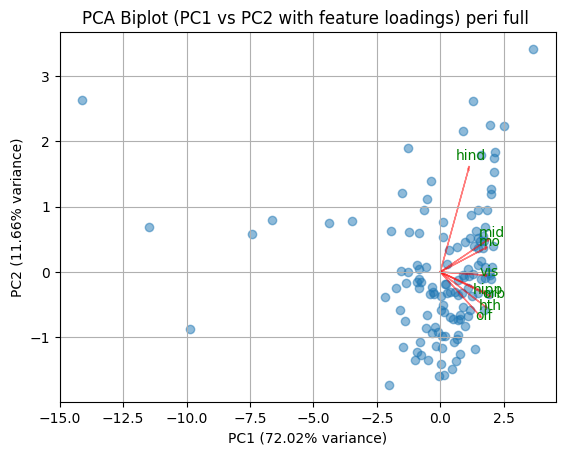

In [75]:
perform_pca_and_visualize(pca_full, "peri full")

Explained variance ratio: [0.74340304 0.12650198]
Cumulative explained variance: [0.74340304 0.86990501]

Top contributing features to PC1:
orb    0.948812
mid    0.929816
mo     0.889468
vis    0.875192
hth    0.873731
Name: PC1, dtype: float64

Top contributing features to PC2:
hind    0.615072
olf     0.453464
hth     0.361276
hipp    0.319725
mid     0.273593
Name: PC2, dtype: float64


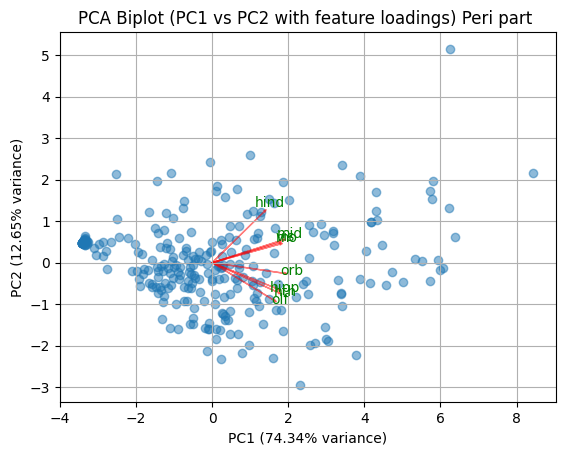

In [76]:
perform_pca_and_visualize(pca_part, "Peri part")

### PCA in Full Network

Explained variance ratio: [0.70176658 0.12346358]
Cumulative explained variance: [0.70176658 0.82523016]

Top contributing features to PC1:
orb    0.969027
mid    0.926996
hth    0.867817
vis    0.863071
mo     0.857217
Name: PC1, dtype: float64

Top contributing features to PC2:
hind    0.797228
hth     0.295629
mo      0.294549
hipp    0.231178
mid     0.226986
Name: PC2, dtype: float64


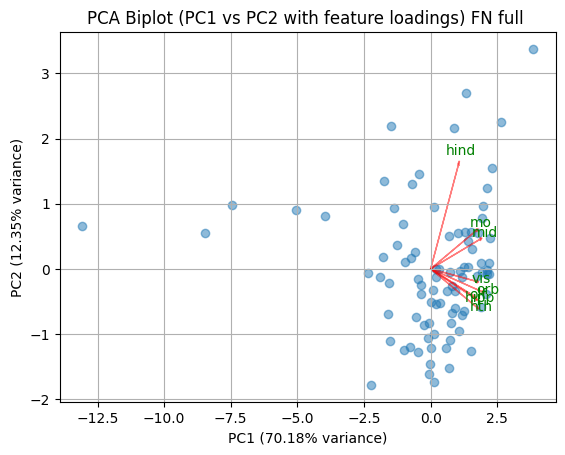

In [65]:

perform_pca_and_visualize(pca_full, "FN full")



Explained variance ratio: [0.70176658 0.12346358]
Cumulative explained variance: [0.70176658 0.82523016]

Top contributing features to PC1:
orb    0.969027
mid    0.926996
hth    0.867817
vis    0.863071
mo     0.857217
Name: PC1, dtype: float64

Top contributing features to PC2:
hind    0.797228
hth     0.295629
mo      0.294549
hipp    0.231178
mid     0.226986
Name: PC2, dtype: float64


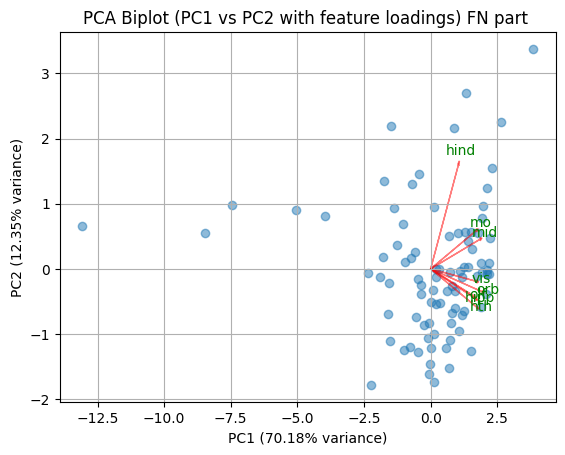

In [66]:
perform_pca_and_visualize(pca_full, "FN part")

### PCA in PERI

In [48]:
avg_comm_per=comm_partcptn.compute_community_participation()

StopIteration: 

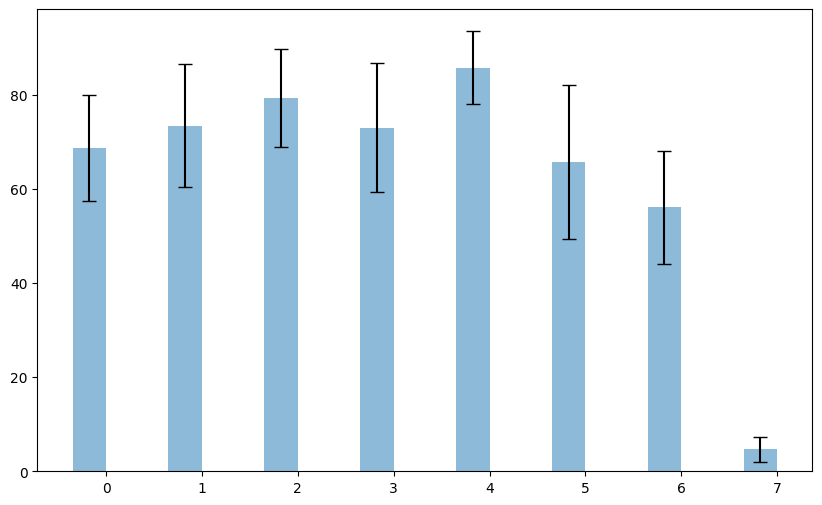

In [49]:


# Convert dict keys and values to lists for easy plotting
keys_full = list(avg_comm_per['avg_full'].keys())
vals_full = list(avg_comm_per['avg_full'].values())
std_full = list(avg_comm_per['std_full'].values())

keys_part = list(avg_comm_per['avg_part'].keys())
vals_part = list(avg_comm_per['avg_part'].values())
std_part = list(avg_comm_per['std_part'].values())

# Ensure keys match order (assuming same keys in both dicts)
x = np.arange(len(keys_full))
width = 0.35

plt.figure(figsize=(10,6))

# Full transitions with error bars
plt.bar(x - width/2,
        vals_full,
        width=width,
        yerr=std_full,
        capsize=5,
        alpha=0.5,
        label='Full Transitions')

# Partial transitions with error bars
plt.bar(x + width/2,
        vals_part,
        width=width,
        yerr=std_part,
        capsize=5,
        alpha=0.5,
        color='orange',
        label='Partial Transitions')

# Labels and title
plt.xticks(x, keys_full, rotation=45)
plt.title('Average percentage Community Participation in Full and Partial Transitions FN')
plt.ylabel('Average % Participation')
plt.legend()
plt.tight_layout()
plt.show()


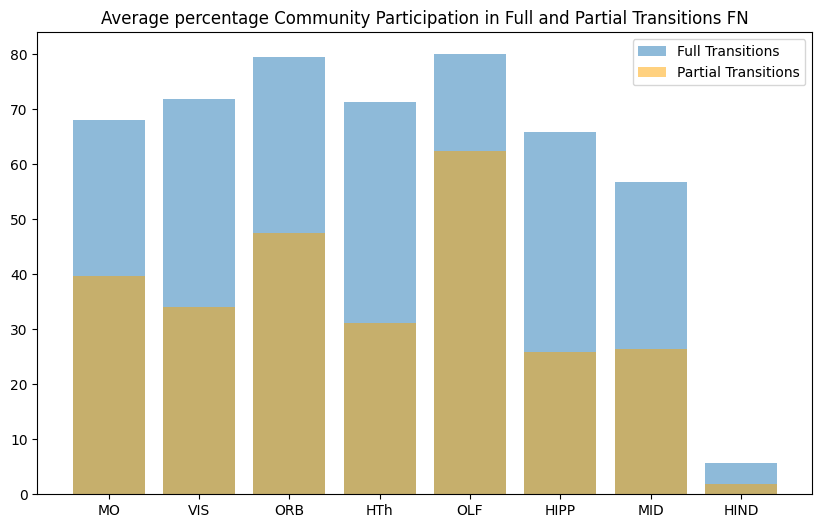

In [ ]:
#names=reader.get_communities()['name_seq']
# fig,(ax1,ax2)=plt.subplots(1,2, figsize=(12,6))
# ax1.bar(avg_comm_per['avg_full'].keys(), avg_comm_per['avg_full'].values())
# ax2.bar(avg_comm_per['avg_part'].keys(), avg_comm_per['avg_part'].values())

plt.figure(figsize=(10,6))
plt.bar(avg_comm_per['avg_full'].keys(), avg_comm_per['avg_full'].values(),alpha=0.5, label='Full Transitions')
plt.bar(avg_comm_per['avg_part'].keys(), avg_comm_per['avg_part'].values(),alpha=0.5, label='Partial Transitions',color='orange')
plt.title('Average percentage Community Participation in Full and Partial Transitions FN')
plt.legend()
plt.show()

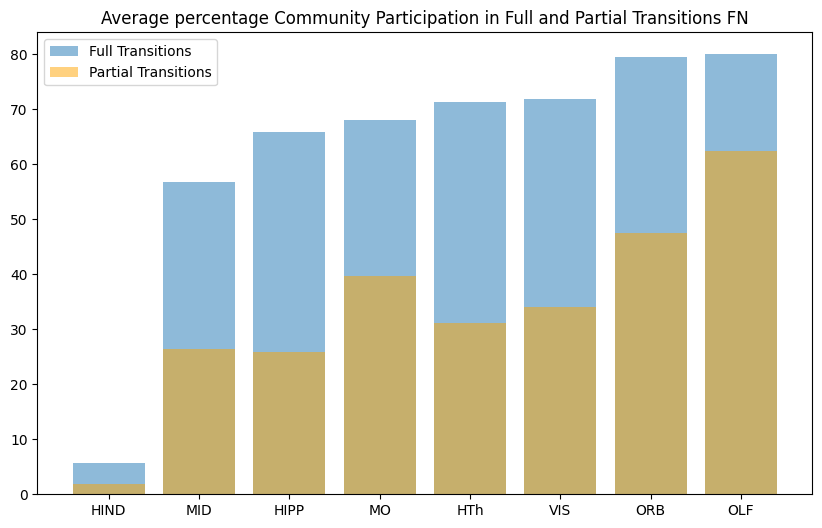

In [ ]:
import matplotlib.pyplot as plt

# Sort 'Full Transitions' by value
full_sorted = dict(sorted(avg_comm_per['avg_full'].items(), key=lambda x: x[1]))

# Reorder 'Partial Transitions' to match the order of 'Full Transitions' keys
part_sorted = {k: avg_comm_per['avg_part'].get(k, 0) for k in full_sorted.keys()}

plt.figure(figsize=(10,6))
plt.bar(full_sorted.keys(), full_sorted.values(), alpha=0.5, label='Full Transitions')
plt.bar(part_sorted.keys(), part_sorted.values(), alpha=0.5, label='Partial Transitions', color='orange')

plt.title('Average percentage Community Participation in Full and Partial Transitions FN')
plt.legend()
plt.show()



#### 

In [ ]:
df_peri_nc=reader.data_read_bz2("raw/workstation/tes_peri_nc.bz2")
df_peri=reader.data_read_bz2("raw/workstation/tes_peri_go.bz2")

In [ ]:

get_avg_comm_particptn(df_peri,df_peri_nc)

0


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


1


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


2


...

full: [84.07361111111112, 80.2, 82.7125]
22 0


c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


this cell
part: [35.29190207156309, 46.75285884963304, 40.222068541570614, 81.39444444444445, 64.20727205610926, 75.25045537340618, 80.01404987706357, 30.547504025764894, 40.404699738903396, 35.45833333333333, 44.25636574074074, 74.63299663299662, 51.321954484605094, 19.711694201490122, 35.84757834757835, 44.55803387030153]
23 0
part: [35.29190207156309, 46.75285884963304, 40.222068541570614, 81.39444444444445, 64.20727205610926, 75.25045537340618, 80.01404987706357, 30.547504025764894, 40.404699738903396, 35.45833333333333, 44.25636574074074, 74.63299663299662, 51.321954484605094, 19.711694201490122, 35.84757834757835, 44.55803387030153, 45.233399079552925]
23 1
part: [35.29190207156309, 46.75285884963304, 40.222068541570614, 81.39444444444445, 64.20727205610926, 75.25045537340618, 80.01404987706357, 30.547504025764894, 40.404699738903396, 35.45833333333333, 44.25636574074074, 74.63299663299662, 51.321954484605094, 19.711694201490122, 35.84757834757835, 44.55803387030153, 45.233399079

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


part: [35.29190207156309, 46.75285884963304, 40.222068541570614, 81.39444444444445, 64.20727205610926, 75.25045537340618, 80.01404987706357, 30.547504025764894, 40.404699738903396, 35.45833333333333, 44.25636574074074, 74.63299663299662, 51.321954484605094, 19.711694201490122, 35.84757834757835, 44.55803387030153, 45.233399079552925, 48.229499467518636, 80.7611111111111]
24 0
part: [35.29190207156309, 46.75285884963304, 40.222068541570614, 81.39444444444445, 64.20727205610926, 75.25045537340618, 80.01404987706357, 30.547504025764894, 40.404699738903396, 35.45833333333333, 44.25636574074074, 74.63299663299662, 51.321954484605094, 19.711694201490122, 35.84757834757835, 44.55803387030153, 45.233399079552925, 48.229499467518636, 80.7611111111111, 69.4478527607362]
24 1


In [ ]:
avg_comm_per=comm_partcptn.compute_community_participation()

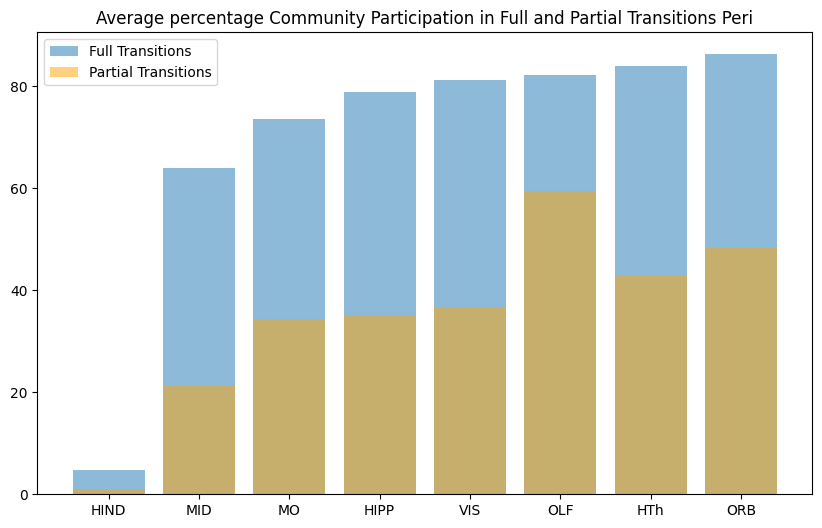

In [ ]:
import matplotlib.pyplot as plt

# Sort 'Full Transitions' by value
full_sorted = dict(sorted(avg_comm_per['avg_full'].items(), key=lambda x: x[1]))

# Reorder 'Partial Transitions' to match the order of 'Full Transitions' keys
part_sorted = {k: avg_comm_per['avg_part'].get(k, 0) for k in full_sorted.keys()}

plt.figure(figsize=(10,6))
plt.bar(full_sorted.keys(), full_sorted.values(), alpha=0.5, label='Full Transitions')
plt.bar(part_sorted.keys(), part_sorted.values(), alpha=0.5, label='Partial Transitions', color='orange')

plt.title('Average percentage Community Participation in Full and Partial Transitions Peri')
plt.legend()
plt.show()



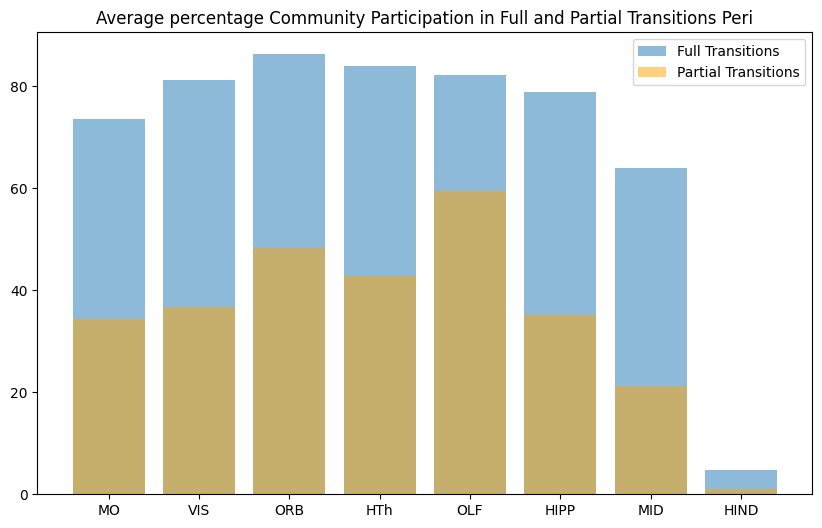

In [ ]:
plt.figure(figsize=(10,6))
plt.bar(avg_comm_per['avg_full'].keys(), avg_comm_per['avg_full'].values(),alpha=0.5, label='Full Transitions')
plt.bar(avg_comm_per['avg_part'].keys(), avg_comm_per['avg_part'].values(),alpha=0.5, label='Partial Transitions',color='orange')
plt.title('Average percentage Community Participation in Full and Partial Transitions Peri')
plt.legend()
plt.show()

In [ ]:
# full network
param_fn=algo.compute_param_df(df_fn)

In [ ]:
param_fn[0]

{'n_part': 20,
 'n_full': 10,
 'n_total': 30,
 'itr_tran': [0,
  1,
  2,
  5,
  6,
  7,
  8,
  10,
  11,
  12,
  13,
  14,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24]}

In [ ]:
param_peri = algo.compute_param_df(df_peri)

In [ ]:
param_peri[0]

{'n_part': 18,
 'n_full': 5,
 'n_total': 23,
 'itr_tran': [4, 5, 6, 10, 11, 12, 13, 14, 15, 17, 19, 21, 22, 23, 24]}

In [ ]:
pts=algoumap.compute_parameters(df_peri[5])
# algoumap.plot_transition()

c:\Users\NSharma\anaconda3\envs\umap310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
algoumap.plot_transition(df_peri[5],pts['start_points'],pts['stop_points'])

In [ ]:
df_loc_peri.loc[5].iloc[0:426]

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
0,0.167406,0.176834,0.186374,0.195959,0.205529,0.215028,0.224408,0.233623,0.242636,0.251413,...,0.472650,0.470164,0.467538,0.464771,0.461860,0.458803,0.455593,0.452228,0.448702,0.445009
1,0.105868,0.109681,0.113445,0.117153,0.120795,0.124365,0.127856,0.131263,0.134582,0.137809,...,0.175068,0.171374,0.167580,0.163687,0.159696,0.155610,0.151431,0.147161,0.142804,0.138365
2,0.116790,0.121040,0.125228,0.129341,0.133367,0.137294,0.141110,0.144806,0.148372,0.151799,...,0.258484,0.255481,0.252405,0.249259,0.246047,0.242771,0.239437,0.236049,0.232612,0.229132
3,0.290160,0.297788,0.305172,0.312307,0.319187,0.325805,0.332153,0.338223,0.344005,0.349492,...,0.184771,0.177926,0.170925,0.163785,0.156525,0.149169,0.141741,0.134276,0.126811,0.119395
4,0.065031,0.069161,0.073223,0.077214,0.081130,0.084967,0.088722,0.092390,0.095969,0.099454,...,0.218597,0.211916,0.205196,0.198448,0.191678,0.184895,0.178110,0.171331,0.164569,0.157836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421,0.166991,0.176487,0.186035,0.195595,0.205130,0.214611,0.224013,0.233314,0.242493,0.251534,...,0.360159,0.357768,0.355030,0.351970,0.348617,0.344997,0.341140,0.337075,0.332832,0.328443
422,0.219830,0.225141,0.230379,0.235518,0.240534,0.245405,0.250109,0.254630,0.258950,0.263057,...,0.097852,0.095687,0.093505,0.091306,0.089094,0.086871,0.084638,0.082398,0.080153,0.077907
423,0.127429,0.128883,0.130336,0.131787,0.133236,0.134683,0.136127,0.137566,0.138999,0.140425,...,0.118697,0.115352,0.112288,0.109552,0.107192,0.105249,0.103761,0.102755,0.102253,0.102262
424,0.198280,0.206980,0.215491,0.223796,0.231882,0.239735,0.247342,0.254692,0.261775,0.268582,...,0.142422,0.136249,0.129825,0.123165,0.116281,0.109189,0.101909,0.094460,0.086870,0.079171


In [ ]:
fig,((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2)

ax1.plot(analyse.smooth(df_peri[5].iloc[pts['start_points'][0]-3000:pts['start_points'][0]+2000])) 
ax3.imshow(df_loc_peri.loc[5].iloc[0:426],aspect='auto',cmap='Reds')

ax2.plot(analyse.smooth(df_peri[5].iloc[pts['start_points'][1]-3000:pts['start_points'][1]+2000])) 
ax4.imshow(df_loc_peri.loc[5].iloc[426:852],aspect='auto',cmap='Reds')

In [ ]:
## node community extraction
reader.ext_node_community(df_loc_fn,0.5,"raw/workstation/tes_fn_nc.bz2")

#### Checking node community data

In [ ]:
df_fn_nc = reader.data_read_bz2('raw/workstation/tes_fn_nc.bz2')
df_peri_nc = reader.data_read_bz2('raw/workstation/tes_peri_nc.bz2')

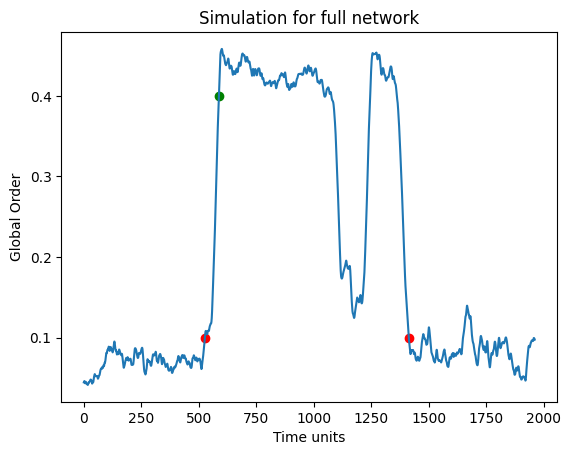

In [ ]:
n=10
analyse.plot_global_synchrony(df_peri[n],0.05)

In [ ]:
df_peri_nc.loc[n].shape


(10000, 426)

1


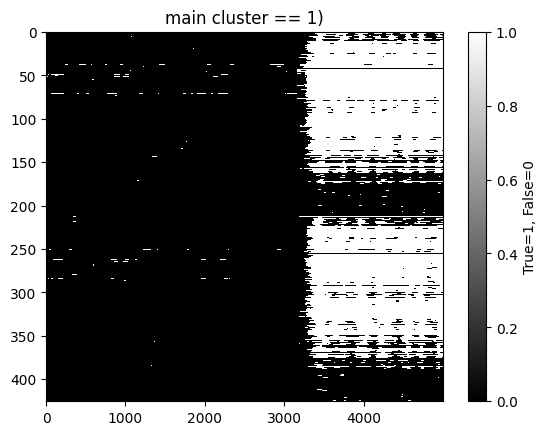

In [ ]:

nc_array = df_peri_nc.loc[n].iloc[0:5000].values
nc=nc_array.copy()
mc = analyse.compute_main_cluster(df_peri_nc.loc[n].iloc[0:5000])
print(mc)

binary_mask = np.isclose(nc, mc)

# Visualize binary mask
plt.imshow(binary_mask.T, cmap='gray', interpolation='nearest', aspect = 'auto')
plt.title(f"main cluster == {mc})")
plt.colorbar(label='True=1, False=0')
plt.show()

In [ ]:
bm=binary_mask.T
id=bm[:,3999]
s_r=bm[id,:]

In [ ]:
row_numbers = np.where(bm[:, 3999])[0]

In [ ]:
row_numbers

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  74,  75,  76,  77,  78,  79,
        80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,
        93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105,
       106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118,
       119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131,
       132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 144, 145,
       146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 158, 159,
       160, 161, 162, 166, 167, 168, 173, 174, 190, 213, 214, 215, 216,
       217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 22

In [ ]:
#Map rows to community

comm_dict=reader.get_communities()

In [ ]:
l_communities=reader.data_read_pkl("connectivity_matrix/mb_communities_dict.pickle")

In [ ]:
community_names = {
        0: "MO",
        1: "MID",
        2: "VIS",
        3: "ORB",
        4: "HTh",
        5: "HIND",
        6: "OLF",
        7: "HIPP",
    }
communities = {community_names[i]: v for i, v in l_communities.items()}

In [ ]:
df_comm_map=comm_dict['comm_map']

In [ ]:
comm_dict['comm_val']

MO      56
VIS     50
ORB     34
HTh     44
OLF     36
HIPP    50
MID     70
HIND    86
dtype: int64

In [ ]:
df_comm_map.index

Int64Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
            ...
            416, 417, 418, 419, 420, 421, 422, 423, 424, 425],
           dtype='int64', length=426)

In [ ]:
mo_c=0
vis_c=0
orb_c=0
hth_c=0
olf_c=0
hipp_c=0
mid_c=0
hind_c=0


for element in  row_numbers:
    if element in communities['MO']:
        mo_c+=1
    elif element in communities['VIS']:
        vis_c+=1
    elif element in communities['ORB']:
        orb_c+=1
    elif element in communities['HTh']:
        hth_c+=1
    elif element in communities['OLF']:
        olf_c+=1    
    elif element in communities['HIPP']:
        hipp_c+=1
    elif element in communities['MID']:
        mid_c+=1    
    elif element in communities['HIND']:
        hind_c+=1   
        
comm_name = comm_dict['comm_val'].index.tolist()
comm_count=dict(zip(comm_name,[mo_c,vis_c,orb_c,hth_c,olf_c,hipp_c,mid_c,hind_c]))
per_comm={}
for name, total in comm_dict['comm_val'].items():
    print(f'{name} {(comm_count[name]/total)*100}%')
    per_comm[f'{name}']=(comm_count[name]/total)*100



MO 100.0%
VIS 100.0%
ORB 100.0%
HTh 97.72727272727273%
OLF 94.44444444444444%
HIPP 100.0%
MID 85.71428571428571%
HIND 4.651162790697675%


In [ ]:
per_comm

{'MO': 100.0,
 'VIS': 100.0,
 'ORB': 100.0,
 'HTh': 97.72727272727273,
 'OLF': 94.44444444444444,
 'HIPP': 100.0,
 'MID': 85.71428571428571,
 'HIND': 4.651162790697675}

In [ ]:
mc = analyse.compute_main_cluster(df_fn_nc.loc[n])

In [ ]:
n=2
df_fn_nc.loc[2].shape

(10000, 426)

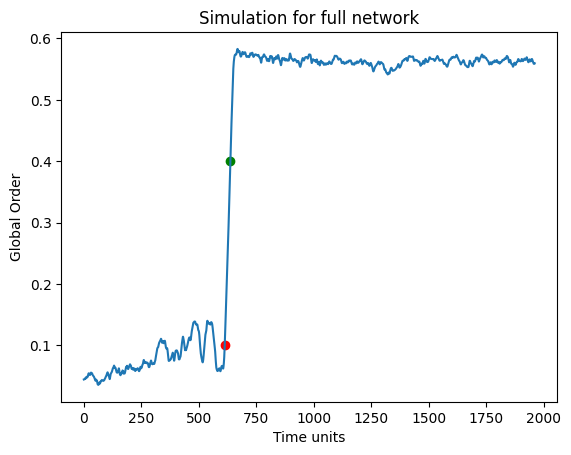

In [ ]:
n=1
analyse.plot_global_synchrony(df_fn[n],0.05)

In [ ]:
n=10
mc=analyse.compute_main_cluster(df_peri_nc.loc[n].iloc[0:5000])
nc=df_peri_nc.loc[n].iloc[0:5000].values
get_node(nc, mc)

{'MO': 82.14285714285714,
 'VIS': 100.0,
 'ORB': 100.0,
 'HTh': 100.0,
 'OLF': 91.66666666666666,
 'HIPP': 92.0,
 'MID': 74.28571428571429,
 'HIND': 3.488372093023256}

In [ ]:
def get_node(nc_array,mc):
    nc=nc_array.copy()
    
    binary_mask = np.isclose(nc, mc)
    bm=binary_mask.T
    row_numbers = np.where(bm[:, 3999])[0]

    mo_c=0
    vis_c=0
    orb_c=0
    hth_c=0
    olf_c=0
    hipp_c=0
    mid_c=0
    hind_c=0


    for element in  row_numbers:
        if element in communities['MO']:
            mo_c+=1
        elif element in communities['VIS']:
            vis_c+=1
        elif element in communities['ORB']:
            orb_c+=1
        elif element in communities['HTh']:
            hth_c+=1
        elif element in communities['OLF']:
            olf_c+=1    
        elif element in communities['HIPP']:
            hipp_c+=1
        elif element in communities['MID']:
            mid_c+=1    
        elif element in communities['HIND']:
            hind_c+=1   
            
    
   
    
    comm_name = comm_dict['comm_val'].index.tolist()
    comm_count=dict(zip(comm_name,[mo_c,vis_c,orb_c,hth_c,olf_c,hipp_c,mid_c,hind_c]))
    per_comm={}
    for name, total in comm_dict['comm_val'].items():
        #print(f'{name} {(comm_count[name]/total)*100}%')
        per_comm[f'{name}']=(comm_count[name]/total)*100
        
    return per_comm
    

In [ ]:
get_node(nc, mc)

MO 100.0%
VIS 100.0%
ORB 100.0%
HTh 97.72727272727273%
OLF 94.44444444444444%
HIPP 100.0%
MID 85.71428571428571%
HIND 4.651162790697675%


{'MO': 100.0,
 'VIS': 100.0,
 'ORB': 100.0,
 'HTh': 97.72727272727273,
 'OLF': 94.44444444444444,
 'HIPP': 100.0,
 'MID': 85.71428571428571,
 'HIND': 4.651162790697675}

In [ ]:
comm_count

{'MO': 56,
 'VIS': 50,
 'ORB': 34,
 'HTh': 43,
 'OLF': 34,
 'HIPP': 50,
 'MID': 60,
 'HIND': 4}

In [ ]:
comm_dict['comm_val'].index.tolist()

['MO', 'VIS', 'ORB', 'HTh', 'OLF', 'HIPP', 'MID', 'HIND']